# From Mean-Variance to the CAPM

In HW 0 you solved one investor's portfolio problem. This page asks what
happens when *every* investor solves it. The answer is the Capital Asset
Pricing Model (CAPM), the theory behind the market index you build in HW 1.
It gives statements and intuition only. Each step links to the paper where
the result is proved.

The figures use ten well-known stocks from CRSP (Apple, Microsoft, Exxon,
J&J, Walmart, Coca-Cola, JPMorgan, GE, Ford, and Disney), monthly from 1990
through 2024. They were picked with hindsight from among today's best-known
companies, so their average returns are higher than a typical stock's. That
does not matter for pictures about risk, but it means these figures are not
a test of anything. The calculations are in
`src/calc_asset_pricing_theory.py`.

In [1]:
import calc_asset_pricing_theory
import figures
from settings import config

OUTPUT_DIR = config("OUTPUT_DIR")
tables = calc_asset_pricing_theory.load_tables(output_dir=OUTPUT_DIR)

## Step 1: One investor holds the tangency portfolio

The **tangency portfolio** is the portfolio of risky assets with the highest
Sharpe ratio. From HW 0, its weights are

$$
w_T \propto \Sigma^{-1}(\mu - r_f \mathbf{1}).
$$

**Statement (Tobin separation).** When there is a risk-free asset, every
mean-variance investor holds the same risky portfolio, the tangency
portfolio. Risk aversion only decides how wealth is split between the
tangency portfolio and the risk-free asset.

**Intuition.** Mixing the risk-free asset with a risky portfolio traces a
straight line that starts at $r_f$, and its slope is that portfolio's Sharpe
ratio. Every investor wants the steepest line, whatever point on it they
pick. A cautious investor lends part of their wealth at $r_f$, and an
aggressive one borrows to hold more than 100% in the tangency portfolio.
Both hold the same mix of risky assets.

In the figure, the gray curve is the frontier of the ten stocks alone.
The blue line is the steepest line from the risk-free asset that still
touches it, and it touches at the tangency portfolio. The two investors sit
on that line, one below the tangency point and one above.

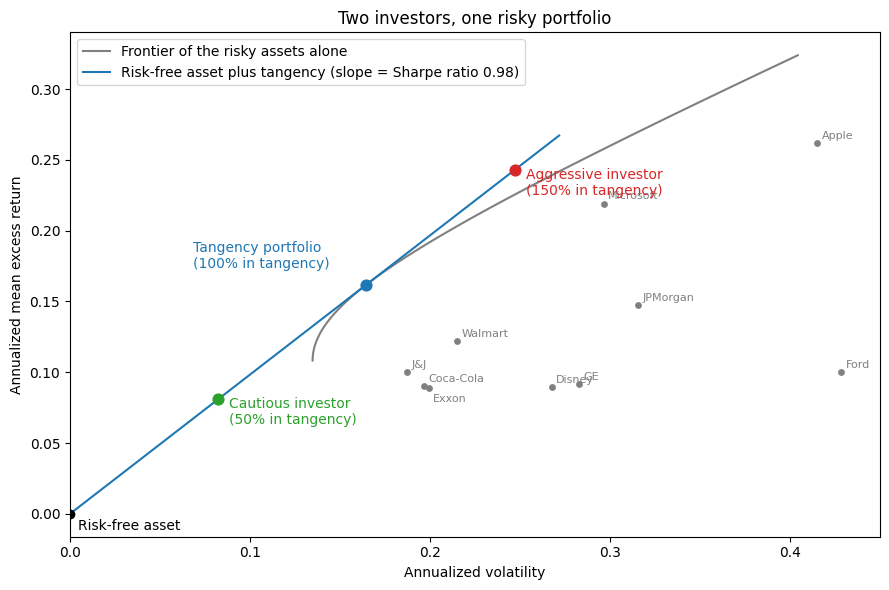

In [2]:
fig = figures.plot_tobin_separation(
    tables["frontier"], tables["asset_points"], tables["tobin_points"]
)

The
[HW 0 appendix](https://finm-32800.github.io/notebooks/_02_markowitz_derivation.html)
proves the general two-fund theorem: without a risk-free asset, every
frontier portfolio mixes the same two funds (Merton 1972). Tobin separation
is the special case where one of the two funds is the risk-free asset.
*Paper: [Tobin (1958)](https://doi.org/10.2307/2296205).*

## Step 2: Two kinds of risk

**Definition.** Regress a stock's excess return on the market's excess
return. This is the *market model* of
[Sharpe (1963)](https://doi.org/10.1287/mnsc.9.2.277):

$$
R_i - r_f = a_i + \beta_i (R_M - r_f) + \varepsilon_i .
$$

The first part, $\beta_i (R_M - r_f)$, is the **systematic** part of the
return. It moves with the whole market. The rest, $\varepsilon_i$, is the
**idiosyncratic** part, which comes from news about the firm itself. The two
parts are uncorrelated, so the variance splits in two:

$$
\sigma_i^2 = \underbrace{\beta_i^2 \sigma_M^2}_{\text{systematic}}
  + \underbrace{\sigma_{\varepsilon_i}^2}_{\text{idiosyncratic}} .
$$

The figure splits Ford's monthly return from 2006 through 2010 into the two
parts. The market part is mostly the 2008 crash, which hit every stock. The
firm-specific part is Ford's own story: the near-bankruptcy of the U.S. auto
industry, then April 2009, when Ford rose 127% while its market part
accounted for 25 points of that.

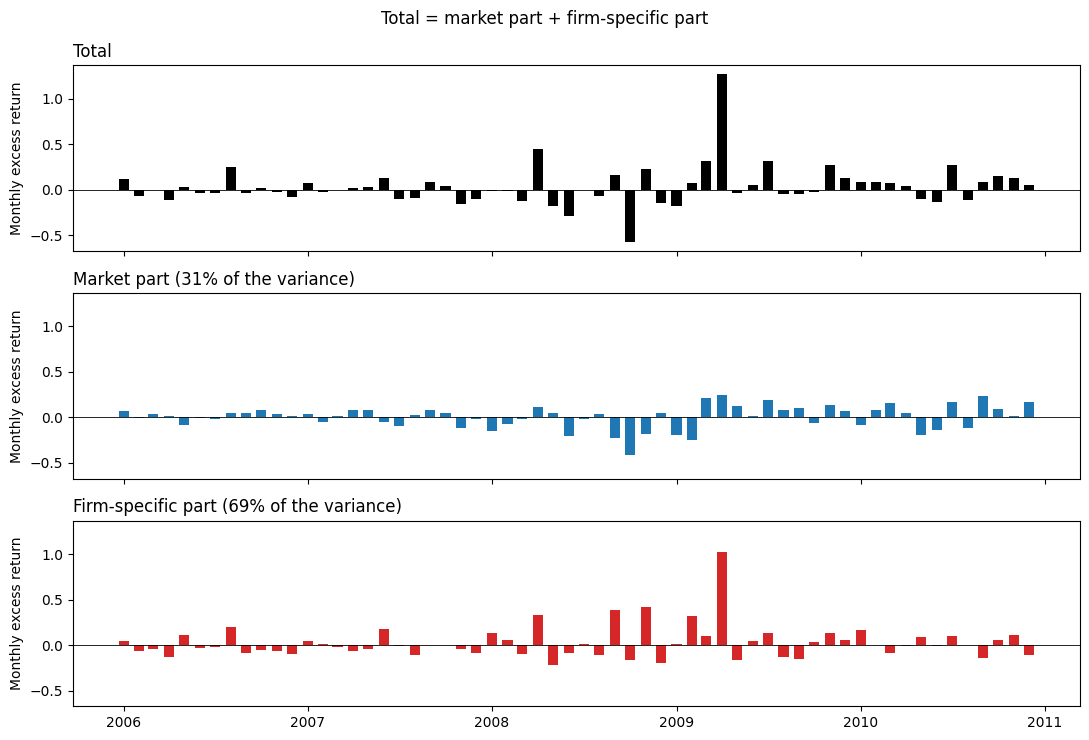

In [3]:
fig = figures.plot_return_decomposition(tables["return_decomposition"])

For most single stocks, idiosyncratic risk is most of the risk. For these
ten, the market explains between 15% (Walmart) and 42% (Disney) of the
variance. Put all ten in one equal-weighted portfolio, and the market
explains 77%.

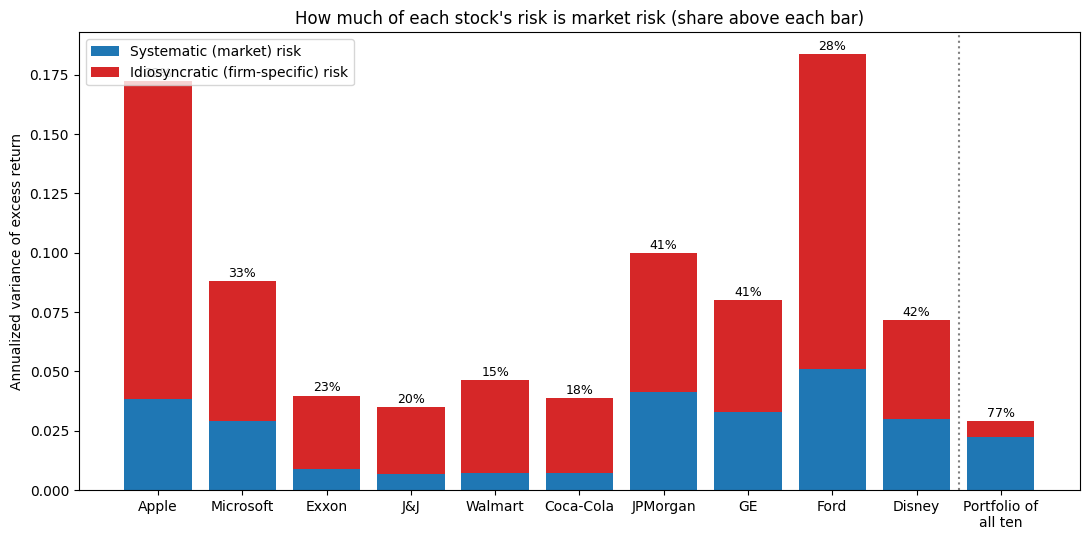

In [4]:
fig = figures.plot_variance_split(tables["risk_split"])

**Statement (diversification).** In a portfolio of many stocks, the
idiosyncratic parts largely cancel and the systematic part remains. In an
equal-weighted portfolio of $N$ stocks, the idiosyncratic variance shrinks
roughly like $1/N$, and the systematic variance stays near the market's.

**Intuition.** Firm-specific news is good for some firms and bad for others,
so across many firms it averages out. Market-wide news hits all of them at
once, so averaging cannot remove it.

The figure draws $N$ stocks at random from every CRSP stock with a full
return history since 1990, 200 times for each $N$, and reports the average
volatility of the equal-weighted portfolio. One stock has a volatility of
38% a year, ten have 20%, and a hundred have 17%, close to the market's 15%.
Past a few dozen stocks, adding more barely helps, because what is left is
systematic risk. *Paper:
[Evans and Archer (1968)](https://doi.org/10.1111/j.1540-6261.1968.tb00315.x).*

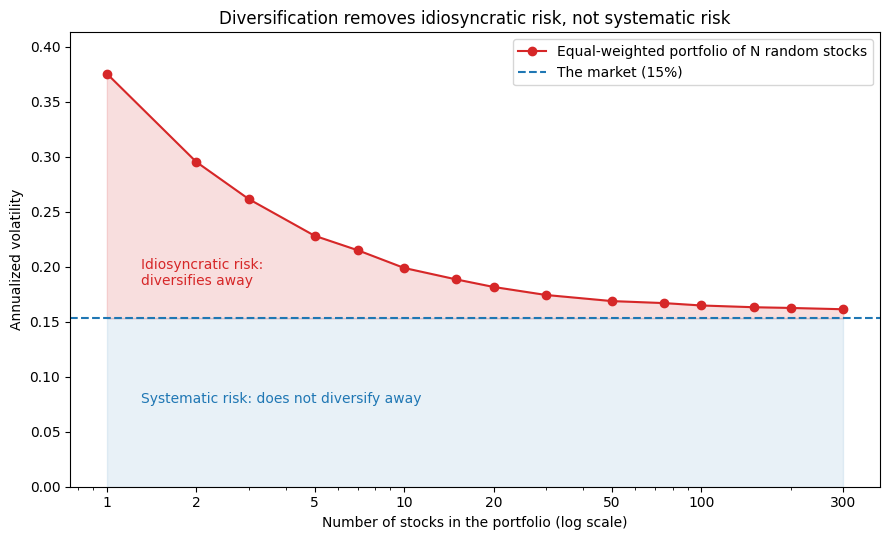

In [5]:
fig = figures.plot_diversification_curve(tables["diversification"])

This is why the single stocks sit far to the right of the frontier in the
Step 1 figure: each carries idiosyncratic risk that a portfolio can shed.
Mean-variance optimization is diversification done optimally. For each
level of expected return, it sheds as much of that risk as it can.

## Step 3: The assumptions

To go from one investor to a market, the CAPM assumes:

- Every investor is a mean-variance optimizer with a one-period horizon.
- Investors agree on $\mu$ and $\Sigma$ (homogeneous beliefs).
- Anyone can borrow or lend any amount at $r_f$. There are no taxes or
  trading costs, and no investor is big enough to move prices.
- **Risky assets are in positive net supply.** They are the shares that
  exist, and their total value is the market capitalization.
- **The risk-free asset is in zero net supply.** It is a loan between
  investors, so every dollar lent is a dollar borrowed.

## Step 4: Supply equals demand, so the market is the tangency portfolio

**Statement.** In equilibrium, the market portfolio, which holds every risky
asset in proportion to its market value, is the tangency portfolio.

**Intuition.** By Step 1, every investor's risky holdings are the same
portfolio at different sizes. Add them up, and total demand for risky assets
is the tangency portfolio, scaled up. Supply is the shares outstanding,
which is the market portfolio. Prices adjust until demand equals supply, and
at those prices the market *is* the tangency portfolio.

The figure shows a made-up economy with three stocks and three investors.
Each investor's stocks come in the same 50/30/20 mix; only the amount
differs. The cautious investor lends \$20, the aggressive investor borrows
\$20, and the moderate investor does neither. Add everyone up and the stocks
are the market, while the risk-free positions sum to zero.

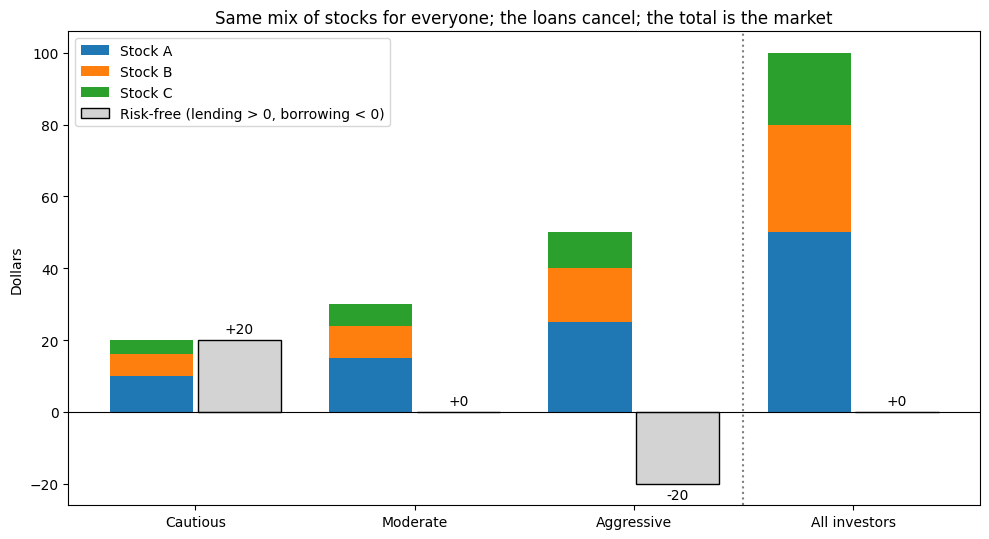

In [6]:
fig = figures.plot_market_clearing(tables["market_clearing"])

Because the risk-free asset is in zero net supply, borrowing and lending
cancel. Investors as a whole hold none of it, and all wealth sits in the
market portfolio. That fixes how large the market risk premium has to be:
large enough that the average investor is willing to hold exactly the
market, no more and no less.

$$
E[R_M] - r_f = \bar\gamma \, \sigma_M^2,
$$

where $\bar\gamma$ is investors' average risk aversion. The premium is larger
when investors are more risk averse or when the market is riskier.

## Step 5: The CAPM

**Statement
([Sharpe 1964](https://doi.org/10.1111/j.1540-6261.1964.tb02865.x),
[Lintner 1965](https://doi.org/10.2307/1924119),
[Mossin 1966](https://doi.org/10.2307/1910098)).** Every asset's expected
excess return is proportional to its beta with the market:

$$
E[R_i] - r_f = \beta_i \big(E[R_M] - r_f\big), \qquad
\beta_i = \frac{\mathrm{Cov}(R_i, R_M)}{\mathrm{Var}(R_M)}.
$$

**Intuition.** Someone who holds the market cares only about the risk of the
whole portfolio. An asset adds to that risk through its covariance with the
market, not through its own variance. The rest of its risk, the
idiosyncratic part, diversifies away, so it earns no reward. Because the
market is already optimal, changing any asset's weight cannot raise the
Sharpe ratio. That only holds if every asset pays the same reward per unit
of market risk it adds, and beta is that unit.

**Only systematic risk is priced.** Since $\beta_i \sigma_M$ is the
systematic part of the stock's volatility, the CAPM can be rewritten as

$$
E[R_i] - r_f =
  \underbrace{\frac{E[R_M] - r_f}{\sigma_M}}_{\text{market Sharpe ratio}}
  \times \underbrace{\beta_i \sigma_M}_{\text{systematic volatility}} .
$$

Each unit of systematic volatility earns the market's Sharpe ratio.
Idiosyncratic volatility earns nothing.

**Intuition.** Anyone can get rid of idiosyncratic risk for free by holding
a diversified portfolio, and in equilibrium everyone does, because they all
hold the market. No one has to be paid to bear a risk they can shed for
free. Systematic risk is different. It is the risk of the market portfolio
itself, someone has to hold it, and so it has to be paid.

In the figure, each gray dot is a stock at its total volatility. The arrow
removes the idiosyncratic risk and moves the stock to its systematic
volatility $\beta_i \sigma_M$, the blue dot. The dashed line runs from the
risk-free asset through the market, and its slope is the market's Sharpe
ratio. The CAPM says that the blue dots lie on that line, not the gray ones:
a stock's reward depends on its systematic risk, however much total risk it
has. Ford and Walmart illustrate this. Ford has twice Walmart's total
volatility, yet it earned less.

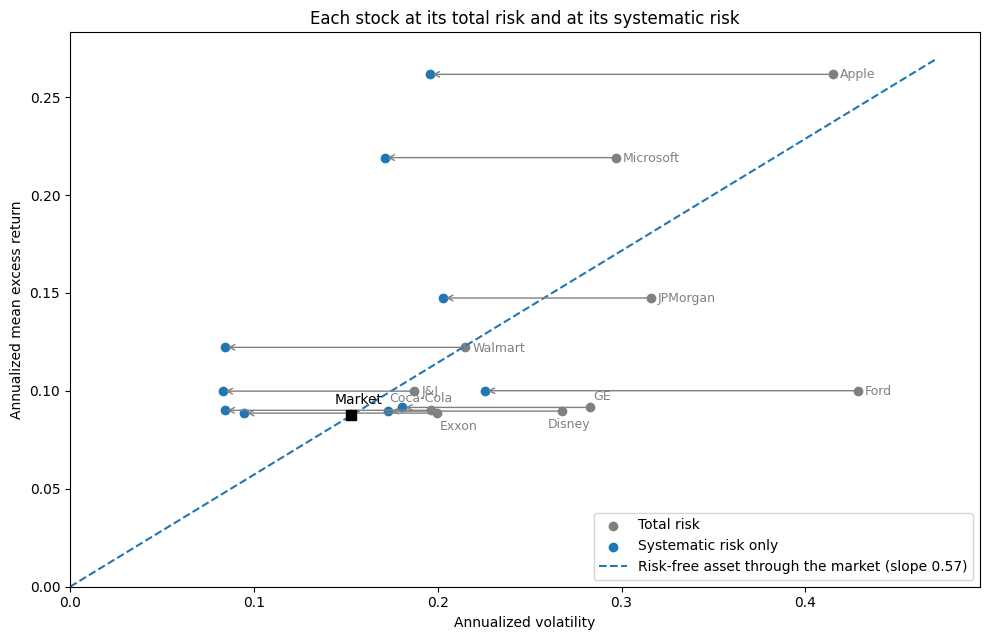

In [7]:
fig = figures.plot_systematic_risk(tables["risk_split"], tables["sml"])

In these data, the blue dots do not land exactly on the line, and Apple and
Microsoft are far above it. That gap is alpha, the subject of Step 6.
Volatilities don't add (only variances do), so an arrow's length is not the
idiosyncratic volatility itself. It shows how far the stock moves once that
risk is gone.

Plotted against beta, the CAPM is a straight line, the **security market
line**. It starts at zero (the risk-free asset has a beta of zero) and passes
through the market at a beta of one. Its slope is the market risk premium.
It is the figure above with beta, rather than $\beta_i \sigma_M$, on the
horizontal axis.

## Step 6: What the CAPM predicts

Regress any portfolio's excess return on the market's excess return:

$$
R_{i,t} - r_{f,t} = \alpha_i + \beta_i (R_{M,t} - r_{f,t}) + \varepsilon_{i,t}.
$$

The CAPM says $\alpha_i = 0$ for every asset: every asset sits on the
security market line, and its alpha is its vertical distance from the line.
This is the same statement as "the market is the tangency portfolio." A
nonzero alpha means some mix of the market and portfolio $i$ has a higher
Sharpe ratio than the market alone
([Gibbons, Ross, and Shanken 1989](https://doi.org/10.2307/1913625)).

The figure plots the ten stocks. The blue line is what the CAPM predicts.
The dashed line is the straight line that fits the stocks best.

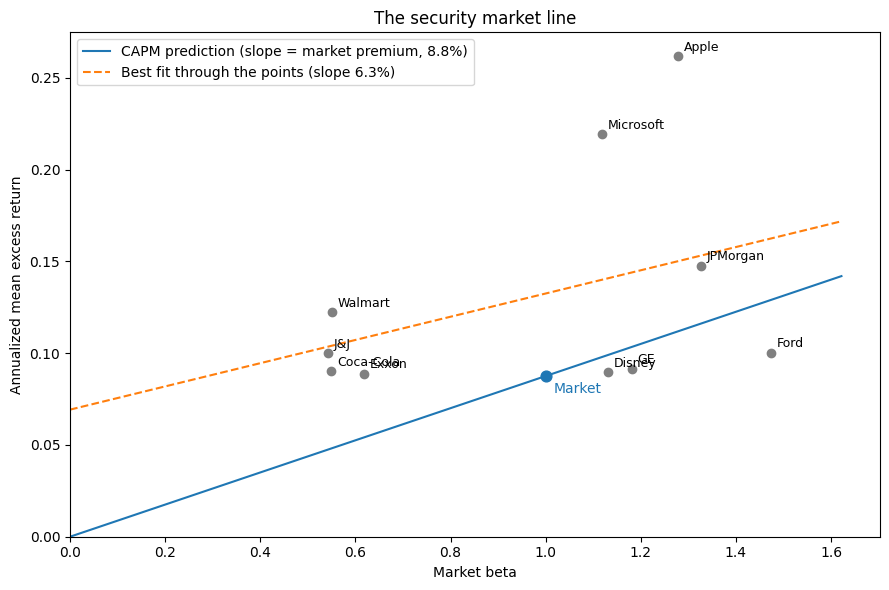

In [8]:
fig = figures.plot_security_market_line(tables["sml"])

In HW 1 you build the market index. Next week,
[HW 1 Guide E](https://finm-32800.github.io/notebooks/_06_CAPM_and_Fama_French_ipynb.html)
runs the alpha test on the portfolios your pipeline builds, and
[From the CAPM to Multifactor Models](https://finm-32800.github.io/notebooks/_08_CAPM_to_multifactor_models_ipynb.html)
explains why more than one factor might be needed.

```{admonition} Discussion
:class: note
The CAPM rests on the assumptions in Step 3. Which are hardest to believe,
and what goes wrong when they fail?
```

Some answers that could come up:

- **The market portfolio cannot be observed
  ([Roll 1977](https://doi.org/10.1016/0304-405X(77)90009-5)).** In theory it
  contains every risky asset: stocks, bonds, real estate, private
  businesses, even human capital. The CRSP value-weighted index is a
  stand-in. A test that rejects the CAPM may only show that the stand-in is
  not efficient, which is why Roll argues the theory cannot really be
  tested.
- **Investors disagree.** If beliefs differ, there is no single tangency
  portfolio for everyone to hold.
- **Borrowing is neither free nor unlimited.** Investors who cannot borrow
  get leverage by buying high-beta stocks instead, which pushes up their
  prices and flattens the relationship between beta and return
  ([Black 1972](https://doi.org/10.1086/295472);
  [Frazzini and Pedersen 2014](https://doi.org/10.1016/j.jfineco.2013.10.005)).
- **The data agree.** The relationship between average returns and beta is
  flatter than the CAPM predicts (Black, Jensen, and Scholes 1972;
  [Fama and French 1992](https://doi.org/10.1111/j.1540-6261.1992.tb04398.x)).
  The dashed line in the figure above is an example.
- **One period.** Real investors also care about what their opportunities
  will look like next year. Dropping this assumption leads to next week's
  multifactor models.
- **Mean and variance only.** Investors may also care about skewness and
  crash risk, which is the subject of HW 3.

## References

- Black, Fischer. "Capital Market Equilibrium with Restricted Borrowing."
  *Journal of Business* 45, no. 3 (1972): 444-455.
- Black, Fischer, Michael C. Jensen, and Myron Scholes. "The Capital Asset
  Pricing Model: Some Empirical Tests." In *Studies in the Theory of
  Capital Markets*, edited by Michael C. Jensen, 79-121. New York: Praeger,
  1972.
- Evans, John L., and Stephen H. Archer. "Diversification and the Reduction
  of Dispersion: An Empirical Analysis." *Journal of Finance* 23, no. 5
  (1968): 761-767.
- Fama, Eugene F., and Kenneth R. French. "The Cross-Section of Expected
  Stock Returns." *Journal of Finance* 47, no. 2 (1992): 427-465.
- Frazzini, Andrea, and Lasse Heje Pedersen. "Betting Against Beta."
  *Journal of Financial Economics* 111, no. 1 (2014): 1-25.
- Gibbons, Michael R., Stephen A. Ross, and Jay Shanken. "A Test of the
  Efficiency of a Given Portfolio." *Econometrica* 57, no. 5 (1989):
  1121-1152.
- Lintner, John. "The Valuation of Risk Assets and the Selection of Risky
  Investments in Stock Portfolios and Capital Budgets." *Review of Economics
  and Statistics* 47, no. 1 (1965): 13-37.
- Merton, Robert C. "An Analytic Derivation of the Efficient Portfolio
  Frontier." *Journal of Financial and Quantitative Analysis* 7, no. 4
  (1972): 1851-1872.
- Mossin, Jan. "Equilibrium in a Capital Asset Market." *Econometrica* 34,
  no. 4 (1966): 768-783.
- Roll, Richard. "A Critique of the Asset Pricing Theory's Tests Part I: On
  Past and Potential Testability of the Theory." *Journal of Financial
  Economics* 4, no. 2 (1977): 129-176.
- Sharpe, William F. "A Simplified Model for Portfolio Analysis."
  *Management Science* 9, no. 2 (1963): 277-293.
- Sharpe, William F. "Capital Asset Prices: A Theory of Market Equilibrium
  under Conditions of Risk." *Journal of Finance* 19, no. 3 (1964): 425-442.
- Tobin, James. "Liquidity Preference as Behavior Towards Risk." *Review of
  Economic Studies* 25, no. 2 (1958): 65-86.